In [13]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('data/train.csv')
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37


In [15]:
for i in df.columns:
    print(df[i].value_counts())

id
1134    1
4       1
253     1
986     1
456     1
       ..
42      1
578     1
353     1
347     1
268     1
Name: count, Length: 912, dtype: int64
laptop_ID
709     1
1284    1
1191    1
280     1
1084    1
       ..
1241    1
767     1
966     1
867     1
1002    1
Name: count, Length: 912, dtype: int64
Company
Lenovo       208
Dell         207
HP           189
Asus         108
Acer          75
Toshiba       37
MSI           34
Apple         17
Mediacom       7
Razer          6
Samsung        6
Fujitsu        3
Microsoft      3
Vero           3
Xiaomi         3
Chuwi          2
Google         2
LG             1
Huawei         1
Name: count, dtype: int64
Product
Inspiron 3567                                21
XPS 13                                       20
250 G6                                       19
Vostro 3568                                  16
ProBook 450                                  11
                                             ..
GL62M (i5-7300HQ/8GB/1TB            

In [16]:
df.describe()

,id,laptop_ID,Inches,Price_euros
count,912.000000,912.000000,912.000000,912.000000
mean,645.091009,666.192982,15.011404,1108.122873
std,380.313813,384.873846,1.411744,714.597741
min,0.000000,1.000000,10.100000,174.000000
25%,319.750000,330.500000,14.000000,589.000000
50%,636.500000,673.500000,15.600000,949.000000
75%,980.250000,998.500000,15.600000,1458.500000
max,1302.000000,1320.000000,18.400000,6099.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   laptop_ID         912 non-null    int64  
 2   Company           912 non-null    object 
 3   Product           912 non-null    object 
 4   TypeName          912 non-null    object 
 5   Inches            912 non-null    float64
 6   ScreenResolution  912 non-null    object 
 7   Cpu               912 non-null    object 
 8   Ram               912 non-null    object 
 9   Memory            912 non-null    object 
 10  Gpu               912 non-null    object 
 11  OpSys             912 non-null    object 
 12  Weight            912 non-null    object 
 13  Price_euros       912 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 99.9+ KB


In [18]:
df[df['Company']=='LG']

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
225,869,686,LG,Gram 15Z975,Ultrabook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.09kg,2299.0


FIRST MODEL ITERATION

<Axes: xlabel='Inches', ylabel='Price_euros'>

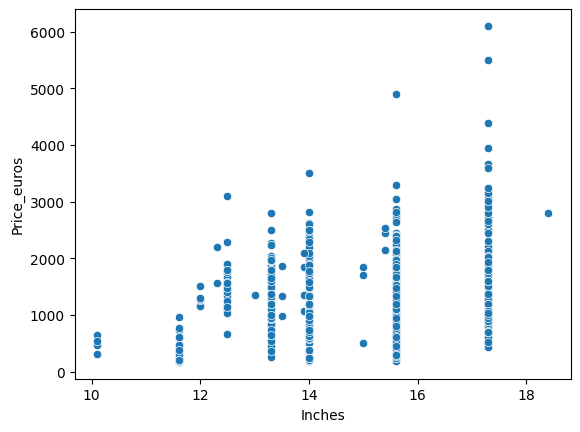

In [19]:
sns.scatterplot(x=df['Inches'], y=df['Price_euros'])

Definimos X y target

In [20]:
X = df['Inches'].values.reshape(-1, 1)
y = df['Price_euros'].values.astype('int').reshape(-1, 1)

Separamos train/test

In [21]:
validation_size = 0.20
seed = 7
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,
                                                                    y,
                                                                    test_size=validation_size,
                                                                    random_state=seed)

Instanciamos modelo y entrenemos

In [22]:
pd.DataFrame(X_train)

,0
0,15.6
1,15.6
2,13.3
3,15.6
4,14.0
...,...
724,17.3
725,15.6
726,13.3
727,17.3


In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [24]:
predictions = model.predict(X_test)
predictions

array([[1121.0707213 ],
       [1081.68576367],
       [1081.68576367],
       [1121.0707213 ],
       [1064.45484471],
       [1064.45484471],
       [1121.0707213 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1081.68576367],
       [1064.45484471],
       [1162.91723877],
       [1064.45484471],
       [1064.45484471],
       [1064.45484471],
       [1121.0707213 ],
       [1081.68576367],
       [1121.0707213 ],
       [1162.91723877],
       [1121.0707213 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1064.45484471],
       [1121.0707213 ],
       [1044.7623659 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1064.45484471],
       [1064.45484471],
       [1121.0707213 ],
       [1064.45484471],
       [1064.45484471],
       [1121.0707213 ],
       [1121.0707213 ],
       [1081.68576367],
       [1121.0707213 ],
       [1162.91723877],
       [1064.45484471],
       [1081.68576367],
       [1032.454

<Axes: >

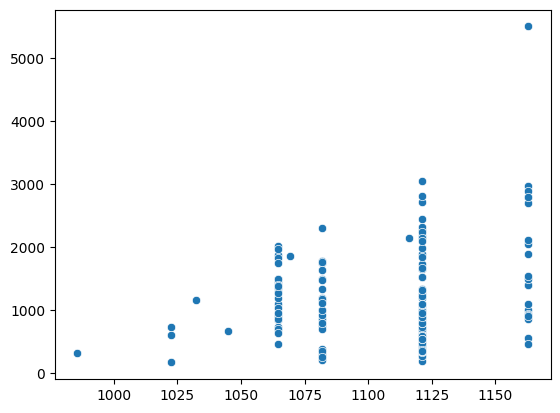

In [25]:
predictions
sns.scatterplot(x=predictions.flatten(), y=Y_test.flatten())

In [26]:
print("MAE:", mean_absolute_error(Y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, predictions)))
print("r2_score train", model.score(X_train, Y_train))
print("r2_score test", model.score(X_test, Y_test))

MAE: 548.580768512684
MAPE: 0.762490744222824
MSE: 527415.783149275
RMSE: 726.2339727314297
r2_score train 0.002445134954987105
r2_score test 0.015368996886242381


In [27]:
kaggle_test = pd.read_csv('data/test.csv')

In [28]:
kaggle_test.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,181,1098,HP,Spectre x360,Ultrabook,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.3kg
1,708,330,Acer,Aspire 5,Notebook,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8GB,256GB SSD,AMD Radeon RX 540,Windows 10,2.2kg
2,862,1260,Acer,Aspire ES1-572,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,500GB HDD,Intel HD Graphics 520,Linux,2.4kg
3,1064,1137,HP,EliteBook 1040,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.43kg
4,702,1015,HP,ENVY -,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.34kg


In [29]:
X_kaggle = kaggle_test['Inches'].values

In [30]:
X_kaggle

array([13.3, 15.6, 15.6, 14. , 13.3, 15.6, 14. , 15.6, 17.3, 14. , 13.3,
       15.6, 13.3, 14. , 15.6, 11.3, 11.6, 13.3, 13.3, 13.3, 17.3, 13.3,
       15.6, 13.3, 17.3, 12.3, 15.6, 15.6, 17.3, 15.6, 13.3, 14. , 15.6,
       15.6, 15.6, 17.3, 15.6, 15.6, 17.3, 15.6, 15.6, 15.6, 13.3, 17.3,
       15.6, 13. , 15.6, 17.3, 15.6, 13.3, 15.6, 17.3, 15.6, 15.6, 13.3,
       13.3, 13.3, 14. , 14. , 15.6, 15.6, 13.5, 15.6, 13.9, 14. , 15.6,
       15.6, 17.3, 17.3, 17.3, 17.3, 17.3, 15.6, 14. , 13.3, 15.6, 15.6,
       15.6, 15.6, 17.3, 11.6, 17.3, 17.3, 14. , 15.6, 13.5, 17.3, 15.6,
       15.6, 15.6, 13.3, 15.6, 15.6, 15.6, 13.3, 17.3, 14. , 15.6, 14. ,
       15.6, 17. , 14. , 13.3, 12.5, 15.6, 13.3, 15.6, 17.3, 14. , 15.6,
       14. , 13.3, 15.6, 15.6, 15.6, 17.3, 15.6, 14. , 15.6, 15. , 15.6,
       15.6, 15.6, 15.6, 14.1, 12.5, 17.3, 14. , 17.3, 13.3, 15.6, 15.6,
       15.6, 12.5, 15.6, 15.6, 11.6, 17.3, 17.3, 15.6, 14. , 14. , 12.5,
       15.6, 17.3, 15.6, 15.6, 15.6, 12.5, 15.6, 14

In [31]:
predictions_kaggle = model.predict(X_kaggle.reshape(-1, 1))
predictions_kaggle

array([[1064.45484471],
       [1121.0707213 ],
       [1121.0707213 ],
       [1081.68576367],
       [1064.45484471],
       [1121.0707213 ],
       [1081.68576367],
       [1121.0707213 ],
       [1162.91723877],
       [1081.68576367],
       [1064.45484471],
       [1121.0707213 ],
       [1064.45484471],
       [1081.68576367],
       [1121.0707213 ],
       [1015.22364768],
       [1022.60832724],
       [1064.45484471],
       [1064.45484471],
       [1064.45484471],
       [1162.91723877],
       [1064.45484471],
       [1121.0707213 ],
       [1064.45484471],
       [1162.91723877],
       [1039.8392462 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1162.91723877],
       [1121.0707213 ],
       [1064.45484471],
       [1081.68576367],
       [1121.0707213 ],
       [1121.0707213 ],
       [1121.0707213 ],
       [1162.91723877],
       [1121.0707213 ],
       [1121.0707213 ],
       [1162.91723877],
       [1121.0707213 ],
       [1121.0707213 ],
       [1121.070

In [32]:
kaggle_test['Price_euros'] = model.predict(X_kaggle.reshape(-1, 1))
kaggle_test.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,181,1098,HP,Spectre x360,Ultrabook,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16GB,512GB SSD,Intel HD Graphics 620,Windows 10,1.3kg,1064.454845
1,708,330,Acer,Aspire 5,Notebook,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8GB,256GB SSD,AMD Radeon RX 540,Windows 10,2.2kg,1121.070721
2,862,1260,Acer,Aspire ES1-572,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,500GB HDD,Intel HD Graphics 520,Linux,2.4kg,1121.070721
3,1064,1137,HP,EliteBook 1040,Notebook,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.43kg,1081.685764
4,702,1015,HP,ENVY -,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.34kg,1064.454845


In [33]:
kaggle_test[['id','Price_euros']].to_csv('sample_submission.csv',index = False, header=True)

KAGGLE CONTEST

In [34]:
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37


In [35]:
#There is too many information in ScreenResolution, we're going to extract all the insights from it, first dividing the ScreenType from Resolution.
pattern = r"^(.*?)(\d{3,4}x\d{3,4})$" #
df[['ScreenType', 'Resolution']] = df['ScreenResolution'].str.extract(pattern)
df['ScreenType'] = df['ScreenType'].str.strip()
df['Resolution'] = df['Resolution'].str.strip()
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,ScreenType,Resolution
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00,,1366x768
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00,,1366x768
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00,Full HD,1920x1080
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99,IPS Panel 4K Ultra HD,3840x2160
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37,Full HD / Touchscreen,1920x1080


Now we are going identify if it has IPS Panel or TouchScreen (most value added to the laptop), and if it is Full HD, 4k Ultra HD etc  
First we take a look and see how many valyes do we have in ScreenType

In [36]:
df['ScreenType'].value_counts()

ScreenType
Full HD                                346
                                       226
IPS Panel Full HD                      165
IPS Panel Full HD / Touchscreen         37
Full HD / Touchscreen                   32
Touchscreen                             24
IPS Panel Retina Display                14
IPS Panel 4K Ultra HD                   10
IPS Panel Touchscreen                    9
4K Ultra HD / Touchscreen                8
IPS Panel                                8
Quad HD+ / Touchscreen                   8
IPS Panel 4K Ultra HD / Touchscreen      8
4K Ultra HD                              5
IPS Panel Quad HD+ / Touchscreen         4
IPS Panel Quad HD+                       2
IPS Panel Touchscreen / 4K Ultra HD      2
Quad HD+                                 2
Touchscreen / Full HD                    1
Touchscreen / 4K Ultra HD                1
Name: count, dtype: int64

Now we have to clasify:
- IPS Panel (y/n)
- Touchscreen (y/n)  
- Retina Display (y/n) (Although is exclusive to Apple/Mac products, it doesn't requiere a lot of work to clasify)  
  
We won't use the Full HD, 4K Ultra HD, etc. Because we can get a numeric feature from Resolution and Inches called PPI (Pixels per Inch), which is from what the labels Full HD and so, come from.

In [37]:
df['IPS_Panel'] = np.where(df['ScreenType'].str.contains('IPS Panel', na=False), 1, 0)
df['Touchscreen'] = np.where(df['ScreenType'].str.contains('Touchscreen', na=False), 1, 0)
df['Retina_Display'] = np.where(df['ScreenType'].str.contains('Retina Display', na=False), 1, 0)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,ScreenType,Resolution,IPS_Panel,Touchscreen,Retina_Display
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00,,1366x768,0,0,0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00,,1366x768,0,0,0
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00,Full HD,1920x1080,0,0,0
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99,IPS Panel 4K Ultra HD,3840x2160,1,0,0
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37,Full HD / Touchscreen,1920x1080,0,1,0


In [38]:
df[['Width','Height']] = df["Resolution"].str.split("x", expand=True).astype(int) #We Split in order to get the individual measures for calculating the PPI
''' 
The PPI formula it's Diagonal Pixels/Screen Size (inches)
The Diagonal Pixles value comes from this operation: √(Width^2 + Height^2)
'''
df['PPI'] = np.round(((np.sqrt(df['Width']**2 + df['Height']**2)) / df['Inches']), 2)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,Weight,Price_euros,ScreenType,Resolution,IPS_Panel,Touchscreen,Retina_Display,Width,Height,PPI
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,...,2.36kg,749.00,,1366x768,0,0,0,1366,768,100.45
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,...,2kg,449.00,,1366x768,0,0,0,1366,768,100.45
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,...,1.2kg,1460.00,Full HD,1920x1080,0,0,0,1920,1080,165.63
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,...,4.42kg,2868.99,IPS Panel 4K Ultra HD,3840x2160,1,0,0,3840,2160,282.42
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,...,1.26kg,1713.37,Full HD / Touchscreen,1920x1080,0,1,0,1920,1080,176.23


Let's clean the weight unit for keeping the numeric value

In [39]:
df['Weight'] = df['Weight'].str.extract(r"(\d+(\.\d+)?)\s*kg")[0].astype(float)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,Weight,Price_euros,ScreenType,Resolution,IPS_Panel,Touchscreen,Retina_Display,Width,Height,PPI
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,...,2.36,749.00,,1366x768,0,0,0,1366,768,100.45
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,...,2.00,449.00,,1366x768,0,0,0,1366,768,100.45
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,...,1.20,1460.00,Full HD,1920x1080,0,0,0,1920,1080,165.63
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,...,4.42,2868.99,IPS Panel 4K Ultra HD,3840x2160,1,0,0,3840,2160,282.42
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,...,1.26,1713.37,Full HD / Touchscreen,1920x1080,0,1,0,1920,1080,176.23


There's also a lot of information in the Memory Column, the steps to follow are: 
1. We'll identify if it has a double slot memory.
2. Identify if at least one of the slots is SSD (y/n), since SSD disks are more expensive than HDDs.
3. Total GB capacity

In [40]:
df['Double_Slot'] = np.where(df['Memory'].str.contains(r'\+', na=False), 1, 0)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,Price_euros,ScreenType,Resolution,IPS_Panel,Touchscreen,Retina_Display,Width,Height,PPI,Double_Slot
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,...,749.00,,1366x768,0,0,0,1366,768,100.45,0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,...,449.00,,1366x768,0,0,0,1366,768,100.45,0
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,...,1460.00,Full HD,1920x1080,0,0,0,1920,1080,165.63,0
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,...,2868.99,IPS Panel 4K Ultra HD,3840x2160,1,0,0,3840,2160,282.42,1
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,...,1713.37,Full HD / Touchscreen,1920x1080,0,1,0,1920,1080,176.23,0


In [41]:
df['SSD'] = np.where(df['Memory'].str.contains(r'\SSD', na=False), 1, 0)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,ScreenType,Resolution,IPS_Panel,Touchscreen,Retina_Display,Width,Height,PPI,Double_Slot,SSD
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,...,,1366x768,0,0,0,1366,768,100.45,0,0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,...,,1366x768,0,0,0,1366,768,100.45,0,0
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,...,Full HD,1920x1080,0,0,0,1920,1080,165.63,0,1
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,...,IPS Panel 4K Ultra HD,3840x2160,1,0,0,3840,2160,282.42,1,1
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,...,Full HD / Touchscreen,1920x1080,0,1,0,1920,1080,176.23,0,1


In [42]:
df['Memory'][df['Memory'].str.contains('TB', na=False)].value_counts()

Memory
1TB HDD                          150
128GB SSD +  1TB HDD              61
256GB SSD +  1TB HDD              52
2TB HDD                           11
512GB SSD +  1TB HDD              10
1TB SSD                            9
1.0TB Hybrid                       7
256GB SSD +  2TB HDD               4
512GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
256GB SSD +  1.0TB Hybrid          1
64GB Flash Storage +  1TB HDD      1
1.0TB HDD                          1
1TB HDD +  1TB HDD                 1
128GB SSD +  2TB HDD               1
512GB SSD +  1.0TB Hybrid          1
Name: count, dtype: int64

For getting the total gb from each Laptop, we'll build a function that exteact each GB and TB info, and sum them up in a new column

In [43]:
import re

def extract_total_memory(storage_string):
    total_gb = 0
    
    gb_pattern = r'(\d+(?:\.\d+)?)\s*GB'
    tb_pattern = r'(\d+(?:\.\d+)?)\s*TB'
    
    gb_matches = re.findall(gb_pattern, storage_string, flags=re.IGNORECASE)
    tb_matches = re.findall(tb_pattern, storage_string, flags=re.IGNORECASE)

    for match in gb_matches:
        total_gb += float(match)

    for match in tb_matches:
        total_gb += float(match) * 1024
    
    return total_gb



In [44]:
df['Total_Memory_gb'] = df['Memory'].apply(extract_total_memory)
df.head()


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,Resolution,IPS_Panel,Touchscreen,Retina_Display,Width,Height,PPI,Double_Slot,SSD,Total_Memory_gb
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,...,1366x768,0,0,0,1366,768,100.45,0,0,1024.0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,...,1366x768,0,0,0,1366,768,100.45,0,0,1024.0
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,...,1920x1080,0,0,0,1920,1080,165.63,0,1,256.0
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,...,3840x2160,1,0,0,3840,2160,282.42,1,1,1280.0
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,...,1920x1080,0,1,0,1920,1080,176.23,0,1,256.0


Let's clean Ram to get only numeric values

In [45]:
df['Ram'] = df['Ram'].str.extract(r"(\d+(\.\d+)?)\s*GB")[0].astype(float)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,Resolution,IPS_Panel,Touchscreen,Retina_Display,Width,Height,PPI,Double_Slot,SSD,Total_Memory_gb
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8.0,1TB HDD,...,1366x768,0,0,0,1366,768,100.45,0,0,1024.0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4.0,1TB HDD,...,1366x768,0,0,0,1366,768,100.45,0,0,1024.0
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,...,1920x1080,0,0,0,1920,1080,165.63,0,1,256.0
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16.0,256GB SSD + 1TB HDD,...,3840x2160,1,0,0,3840,2160,282.42,1,1,1280.0
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8.0,256GB SSD,...,1920x1080,0,1,0,1920,1080,176.23,0,1,256.0


Now it's the OpSys turn. Steps:
1. Classify main OpSys companies.
2. Classify versions

In [46]:
df['OpSys'].value_counts()

OpSys
Windows 10      746
Linux            47
No OS            44
Windows 7        32
Chrome OS        20
macOS            11
Mac OS X          6
Windows 10 S      4
Android           2
Name: count, dtype: int64

In [47]:
def opsys_classifier(opsys):
    if 'Windows' in opsys:
        return 'Windows'
    elif 'Linux' in opsys:
        return 'Linux'
    elif 'mac' in opsys.lower():
        return 'Mac'
    else:
        return opsys

df['OpSys_cpy'] = df['OpSys'].apply(opsys_classifier)
df['OpSys_cpy'].value_counts()

OpSys_cpy
Windows      782
Linux         47
No OS         44
Chrome OS     20
Mac           17
Android        2
Name: count, dtype: int64

Now we'll work with the OpSys versions

In [48]:
def opsys_get_version(opsys):
    if 'Windows' in opsys:
        match = re.search(r'Windows\s*([\d\.]+)', opsys, re.IGNORECASE)
        if match:
            return match.group(1)
        else:
            return 'Windows'
    elif 'mac' in opsys.lower():
        # Convertimos a minúsculas para hacer comparaciones consistentes
        opsys_lower = opsys.lower()
        if 'mac os' in opsys_lower:
            return 1 #mac os refers to olders version of the opsys
        elif 'macos' in opsys_lower:
            return 2 #macos referes to newers ones which may be more expensive
        else:
            return None  # Si no se reconoce, se retorna None (puedes cambiarlo según tus necesidades)
    else:
        return 0
    
df['OpSys_v'] = df['OpSys'].apply(opsys_get_version)
df['OpSys_v'].value_counts()

OpSys_v
10    750
0     113
7      32
2      11
1       6
Name: count, dtype: int64

In [49]:
df = pd.get_dummies(df, columns=['OpSys_cpy'], dtype=int)
df.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,...,Double_Slot,SSD,Total_Memory_gb,OpSys_v,OpSys_cpy_Android,OpSys_cpy_Chrome OS,OpSys_cpy_Linux,OpSys_cpy_Mac,OpSys_cpy_No OS,OpSys_cpy_Windows
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8.0,1TB HDD,...,0,0,1024.0,10,0,0,0,0,0,1
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4.0,1TB HDD,...,0,0,1024.0,10,0,0,0,0,0,1
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,...,0,1,256.0,7,0,0,0,0,0,1
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16.0,256GB SSD + 1TB HDD,...,1,1,1280.0,10,0,0,0,0,0,1
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8.0,256GB SSD,...,0,1,256.0,7,0,0,0,0,0,1


Fpr TypeName, we'll use get_dummies

In [50]:
df = pd.get_dummies(df, columns=['TypeName'], dtype=int)
df.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,OpSys_cpy_Linux,OpSys_cpy_Mac,OpSys_cpy_No OS,OpSys_cpy_Windows,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation
0,268,1002,Dell,Inspiron 5567,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8.0,1TB HDD,AMD Radeon R7 M445,...,0,0,0,1,0,0,0,1,0,0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4.0,1TB HDD,Intel HD Graphics 505,...,0,0,0,1,0,0,0,1,0,0
2,353,966,Toshiba,Portege Z30-C-1CW,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,0,0,1,0,0,0,1,0,0
3,578,767,Dell,Alienware 17,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16.0,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,...,0,0,0,1,0,1,0,0,0,0
4,42,1241,Dell,Latitude E7270,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,0,0,1,0,0,0,0,1,0


For CPU we're getting from the original field:
- Company
- Clock Speed (ghz)  

Due to the complicatios from getting the version, we'll stick with this info, since the clock speed can gives us a pretty good sense of the Cpu status.


In [51]:
df['Cpu_cpy'] = df['Cpu'].str.split(" ").str[0]
df = pd.get_dummies(df, columns=['Cpu_cpy'], dtype=int)
df.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,OpSys_cpy_No OS,OpSys_cpy_Windows,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_cpy_AMD,Cpu_cpy_Intel
0,268,1002,Dell,Inspiron 5567,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8.0,1TB HDD,AMD Radeon R7 M445,...,0,1,0,0,0,1,0,0,0,1
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4.0,1TB HDD,Intel HD Graphics 505,...,0,1,0,0,0,1,0,0,0,1
2,353,966,Toshiba,Portege Z30-C-1CW,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,1,0,0,0,1,0,0,0,1
3,578,767,Dell,Alienware 17,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16.0,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,...,0,1,0,1,0,0,0,0,0,1
4,42,1241,Dell,Latitude E7270,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,1,0,0,0,0,1,0,0,1


In [52]:
df['Cpu_cs'] =df['Cpu'].str.split(' ').str[-1].str.extract(r'([\d\.]+)\s*GHz').astype(float)
df['Cpu_cs'].head()

0    2.7
1    1.1
2    2.3
3    2.8
4    2.4
Name: Cpu_cs, dtype: float64

For the company, we'll assign their current share in Amazon sales for the last month. We've gathered the data from this [website](https://laptopmedia.com/highlights/q4-2024-global-ranking-of-best-selling-laptop-gpus-on-amazon-intel-dominates-apple-shines-in-premium-and-nvidia-flexes-dedicated-muscle/), which analyzes the top 1000 best selling laptops in Amazon.


In [53]:
market_share = {
    "lenovo": 18.5,
    "hp": 16.5,
    "asus": 15.2,
    "apple": 14.2,
    "acer": 11.7,
    "dell": 2.9,
    "msi": 2.9,
    "fujitsu": 1.6,
    "samsung": 1.4,
    "microsoft": 1,
    "huawei": 1,
    "gigabyte": 1,
    "lg": 1,
    "toshiba": 1
}

In [54]:
df['Company_share'] = df['Company'].str.lower().map(market_share).fillna(0)
df.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,TypeName_2 in 1 Convertible,TypeName_Gaming,TypeName_Netbook,TypeName_Notebook,TypeName_Ultrabook,TypeName_Workstation,Cpu_cpy_AMD,Cpu_cpy_Intel,Cpu_cs,Company_share
0,268,1002,Dell,Inspiron 5567,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8.0,1TB HDD,AMD Radeon R7 M445,...,0,0,0,1,0,0,0,1,2.7,2.9
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4.0,1TB HDD,Intel HD Graphics 505,...,0,0,0,1,0,0,0,1,1.1,15.2
2,353,966,Toshiba,Portege Z30-C-1CW,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,0,0,1,0,0,0,1,2.3,1.0
3,578,767,Dell,Alienware 17,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16.0,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,...,0,1,0,0,0,0,0,1,2.8,2.9
4,42,1241,Dell,Latitude E7270,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,0,0,0,1,0,0,1,2.4,2.9


Last but not least, let's work with the Gpu Category

In [55]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      199
Intel HD Graphics 520      138
Intel UHD Graphics 620      45
Nvidia GeForce GTX 1050     43
Nvidia GeForce GTX 1060     31
                          ... 
AMD FirePro W6150M           1
AMD Radeon R7 Graphics       1
AMD Radeon R7                1
Intel Graphics 620           1
Nvidia Quadro M520M          1
Name: count, Length: 91, dtype: int64

We'll get the ranking published in [LaptopMedia](https://laptopmedia.com/top-laptop-graphics-ranking/).

In [56]:
from selenium import webdriver
from bs4 import BeautifulSoup
import pandas as pd
import time

# Set up Selenium WebDriver (you need to install the appropriate driver for your browser)
driver = webdriver.Chrome()  # or use webdriver.Firefox() or any other driver

# Open the URL
url = 'https://laptopmedia.com/top-laptop-graphics-ranking/'
driver.get(url)

time.sleep(5)

html_content = driver.page_source
driver.quit()
soup = BeautifulSoup(html_content, 'html.parser')
table = soup.find('table', {'class': 'w-full text-lm-darkBlue'})

if table:

    rows = table.find_all('tr')

    data = []
    headers = [header.text.strip() for header in rows[0].find_all('th')]  # Get headers
    for row in rows[1:]:
        columns = row.find_all('td')
        if columns:
            data.append([column.text.strip() for column in columns])

    gpu_ranking = pd.DataFrame(data, columns=headers)

gpu_ranking.head()

,#,GPU,3DMark Time Spy (G),Performance Difference,Prices from...,Price Difference
0,1.,"NVIDIA GeForce RTX 4090 (Laptop, 175W)",21474,10%,$2499.99,32%
1,,None,None,None,None,None
2,2.,"NVIDIA GeForce RTX 4080 (Laptop, 175W)",19480,2%,$1899.00,40%
3,,None,None,None,None,None
4,3.,"NVIDIA GeForce RTX 4090 (Laptop, 150W)",19147,7%,$3189.00,-


As we can see there is some work to do with format, we'll keep the GPU name and its ranking

In [57]:
gpu_ranking = gpu_ranking[gpu_ranking['#']!='']
gpu_ranking.head()

,#,GPU,3DMark Time Spy (G),Performance Difference,Prices from...,Price Difference
0,1.,"NVIDIA GeForce RTX 4090 (Laptop, 175W)",21474,10%,$2499.99,32%
2,2.,"NVIDIA GeForce RTX 4080 (Laptop, 175W)",19480,2%,$1899.00,40%
4,3.,"NVIDIA GeForce RTX 4090 (Laptop, 150W)",19147,7%,$3189.00,-
6,4.,"NVIDIA GeForce RTX 4090 (Laptop, 125W)",17885,0%,N/A,-
8,5.,AMD Radeon RX 7800M XT,17842,2%,N/A,-


In [58]:
gpu_ranking = gpu_ranking[['#','GPU']]
gpu_ranking.head()

,#,GPU
0,1.,"NVIDIA GeForce RTX 4090 (Laptop, 175W)"
2,2.,"NVIDIA GeForce RTX 4080 (Laptop, 175W)"
4,3.,"NVIDIA GeForce RTX 4090 (Laptop, 150W)"
6,4.,"NVIDIA GeForce RTX 4090 (Laptop, 125W)"
8,5.,AMD Radeon RX 7800M XT


In [59]:
gpu_ranking['Ranking'] = gpu_ranking['#'].str.replace('.','').astype(int)
gpu_ranking.drop(columns='#', inplace=True)
gpu_ranking.head()

,GPU,Ranking
0,"NVIDIA GeForce RTX 4090 (Laptop, 175W)",1
2,"NVIDIA GeForce RTX 4080 (Laptop, 175W)",2
4,"NVIDIA GeForce RTX 4090 (Laptop, 150W)",3
6,"NVIDIA GeForce RTX 4090 (Laptop, 125W)",4
8,AMD Radeon RX 7800M XT,5


So we can help the model, we'll invert the order, the best ranking will have a higher number, so we can map the Gpu which are not in the list as 0

In [60]:
gpu_ranking['Ranking'] = gpu_ranking['Ranking'].max() + 1 - gpu_ranking['Ranking']
print(gpu_ranking.head())
print(gpu_ranking.tail())

                                      GPU  Ranking
0  NVIDIA GeForce RTX 4090 (Laptop, 175W)      340
2  NVIDIA GeForce RTX 4080 (Laptop, 175W)      339
4  NVIDIA GeForce RTX 4090 (Laptop, 150W)      338
6  NVIDIA GeForce RTX 4090 (Laptop, 125W)      337
8                  AMD Radeon RX 7800M XT      336
                        GPU  Ranking
670   Intel HD Graphics 610        5
672  Intel UHD Graphics 610        4
674  Intel UHD Graphics 605        3
676  Intel UHD Graphics 600        2
678   AMD Radeon R3 (Beema)        1


In [61]:
gpu_ranking['GPU'] = gpu_ranking['GPU'].str.split('(').str[0].str.strip().str.lower()
gpu_ranking.head()

,GPU,Ranking
0,nvidia geforce rtx 4090,340
2,nvidia geforce rtx 4080,339
4,nvidia geforce rtx 4090,338
6,nvidia geforce rtx 4090,337
8,amd radeon rx 7800m xt,336


We're goint to use fuzzywuzzy for the mapping, since the are some Gpus that in firsts iterations didn't, and with this library we can define a function with a treshold for getting the best match, in this case we've setted a 90% of matching for considering the same Gpu.

In [62]:
from fuzzywuzzy import process
def fuzzy_match_gpu(gpu_name, gpu_map, threshold=90):
    # Find the best match from gpu_map keys using fuzzywuzzy's process.extractOne
    best_match, score = process.extractOne(gpu_name.lower(), gpu_map.keys())
    if score >= threshold:  # Match is considered valid if score is above the threshold
        return gpu_map[best_match]
    else:
        return 0  # If no good match, return 0

In [63]:
gpu_map = gpu_ranking.set_index('GPU')['Ranking'].to_dict()
df['Gpu_ranking'] = df['Gpu'].apply(lambda x: fuzzy_match_gpu(x, gpu_map))
df['Gpu'][df['Gpu_ranking']==0.0]

48            Intel Iris Pro Graphics
74             AMD Radeon R2 Graphics
93                 AMD Radeon R9 M385
144               AMD FirePro W4190M 
405               AMD FirePro W4190M 
500    Nvidia GeForce GTX 960<U+039C>
521            AMD Radeon R2 Graphics
551    Nvidia GeForce GTX 960<U+039C>
589                    AMD R17M-M1-70
645            AMD Radeon R4 Graphics
712            AMD Radeon R2 Graphics
738                Nvidia GTX 980 SLI
740                   AMD R4 Graphics
819                AMD FirePro W6150M
900            AMD Radeon R4 Graphics
901            AMD Radeon R2 Graphics
Name: Gpu, dtype: object

Now we'll get the Gpu company and we'll be ready for a quick EDA.

In [64]:
df['Gpu_cpy'] = df['Gpu'].str.split(" ").str[0]
df = pd.get_dummies(df, columns=['Gpu_cpy'], dtype=int)
df.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,TypeName_Ultrabook,TypeName_Workstation,Cpu_cpy_AMD,Cpu_cpy_Intel,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_Intel,Gpu_cpy_Nvidia
0,268,1002,Dell,Inspiron 5567,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8.0,1TB HDD,AMD Radeon R7 M445,...,0,0,0,1,2.7,2.9,32,1,0,0
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4.0,1TB HDD,Intel HD Graphics 505,...,0,0,0,1,1.1,15.2,10,0,1,0
2,353,966,Toshiba,Portege Z30-C-1CW,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,0,0,1,2.3,1.0,10,0,1,0
3,578,767,Dell,Alienware 17,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16.0,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,...,0,0,0,1,2.8,2.9,191,0,0,1
4,42,1241,Dell,Latitude E7270,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8.0,256GB SSD,Intel HD Graphics 520,...,1,0,0,1,2.4,2.9,10,0,1,0


Let's start with a brief EDA

In [65]:
df_numeric = df[['Price_euros','Inches','Ram','Weight','IPS_Panel', 'Touchscreen',
       'Retina_Display','PPI', 'Double_Slot', 'SSD',
       'Total_Memory_gb', 'OpSys_v', 'OpSys_cpy_Android',
       'OpSys_cpy_Chrome OS', 'OpSys_cpy_Linux', 'OpSys_cpy_Mac',
       'OpSys_cpy_No OS', 'OpSys_cpy_Windows', 'TypeName_2 in 1 Convertible',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'Cpu_cpy_AMD',
       'Cpu_cpy_Intel', 'Cpu_cs', 'Company_share', 'Gpu_ranking',
       'Gpu_cpy_AMD', 'Gpu_cpy_Intel', 'Gpu_cpy_Nvidia']]

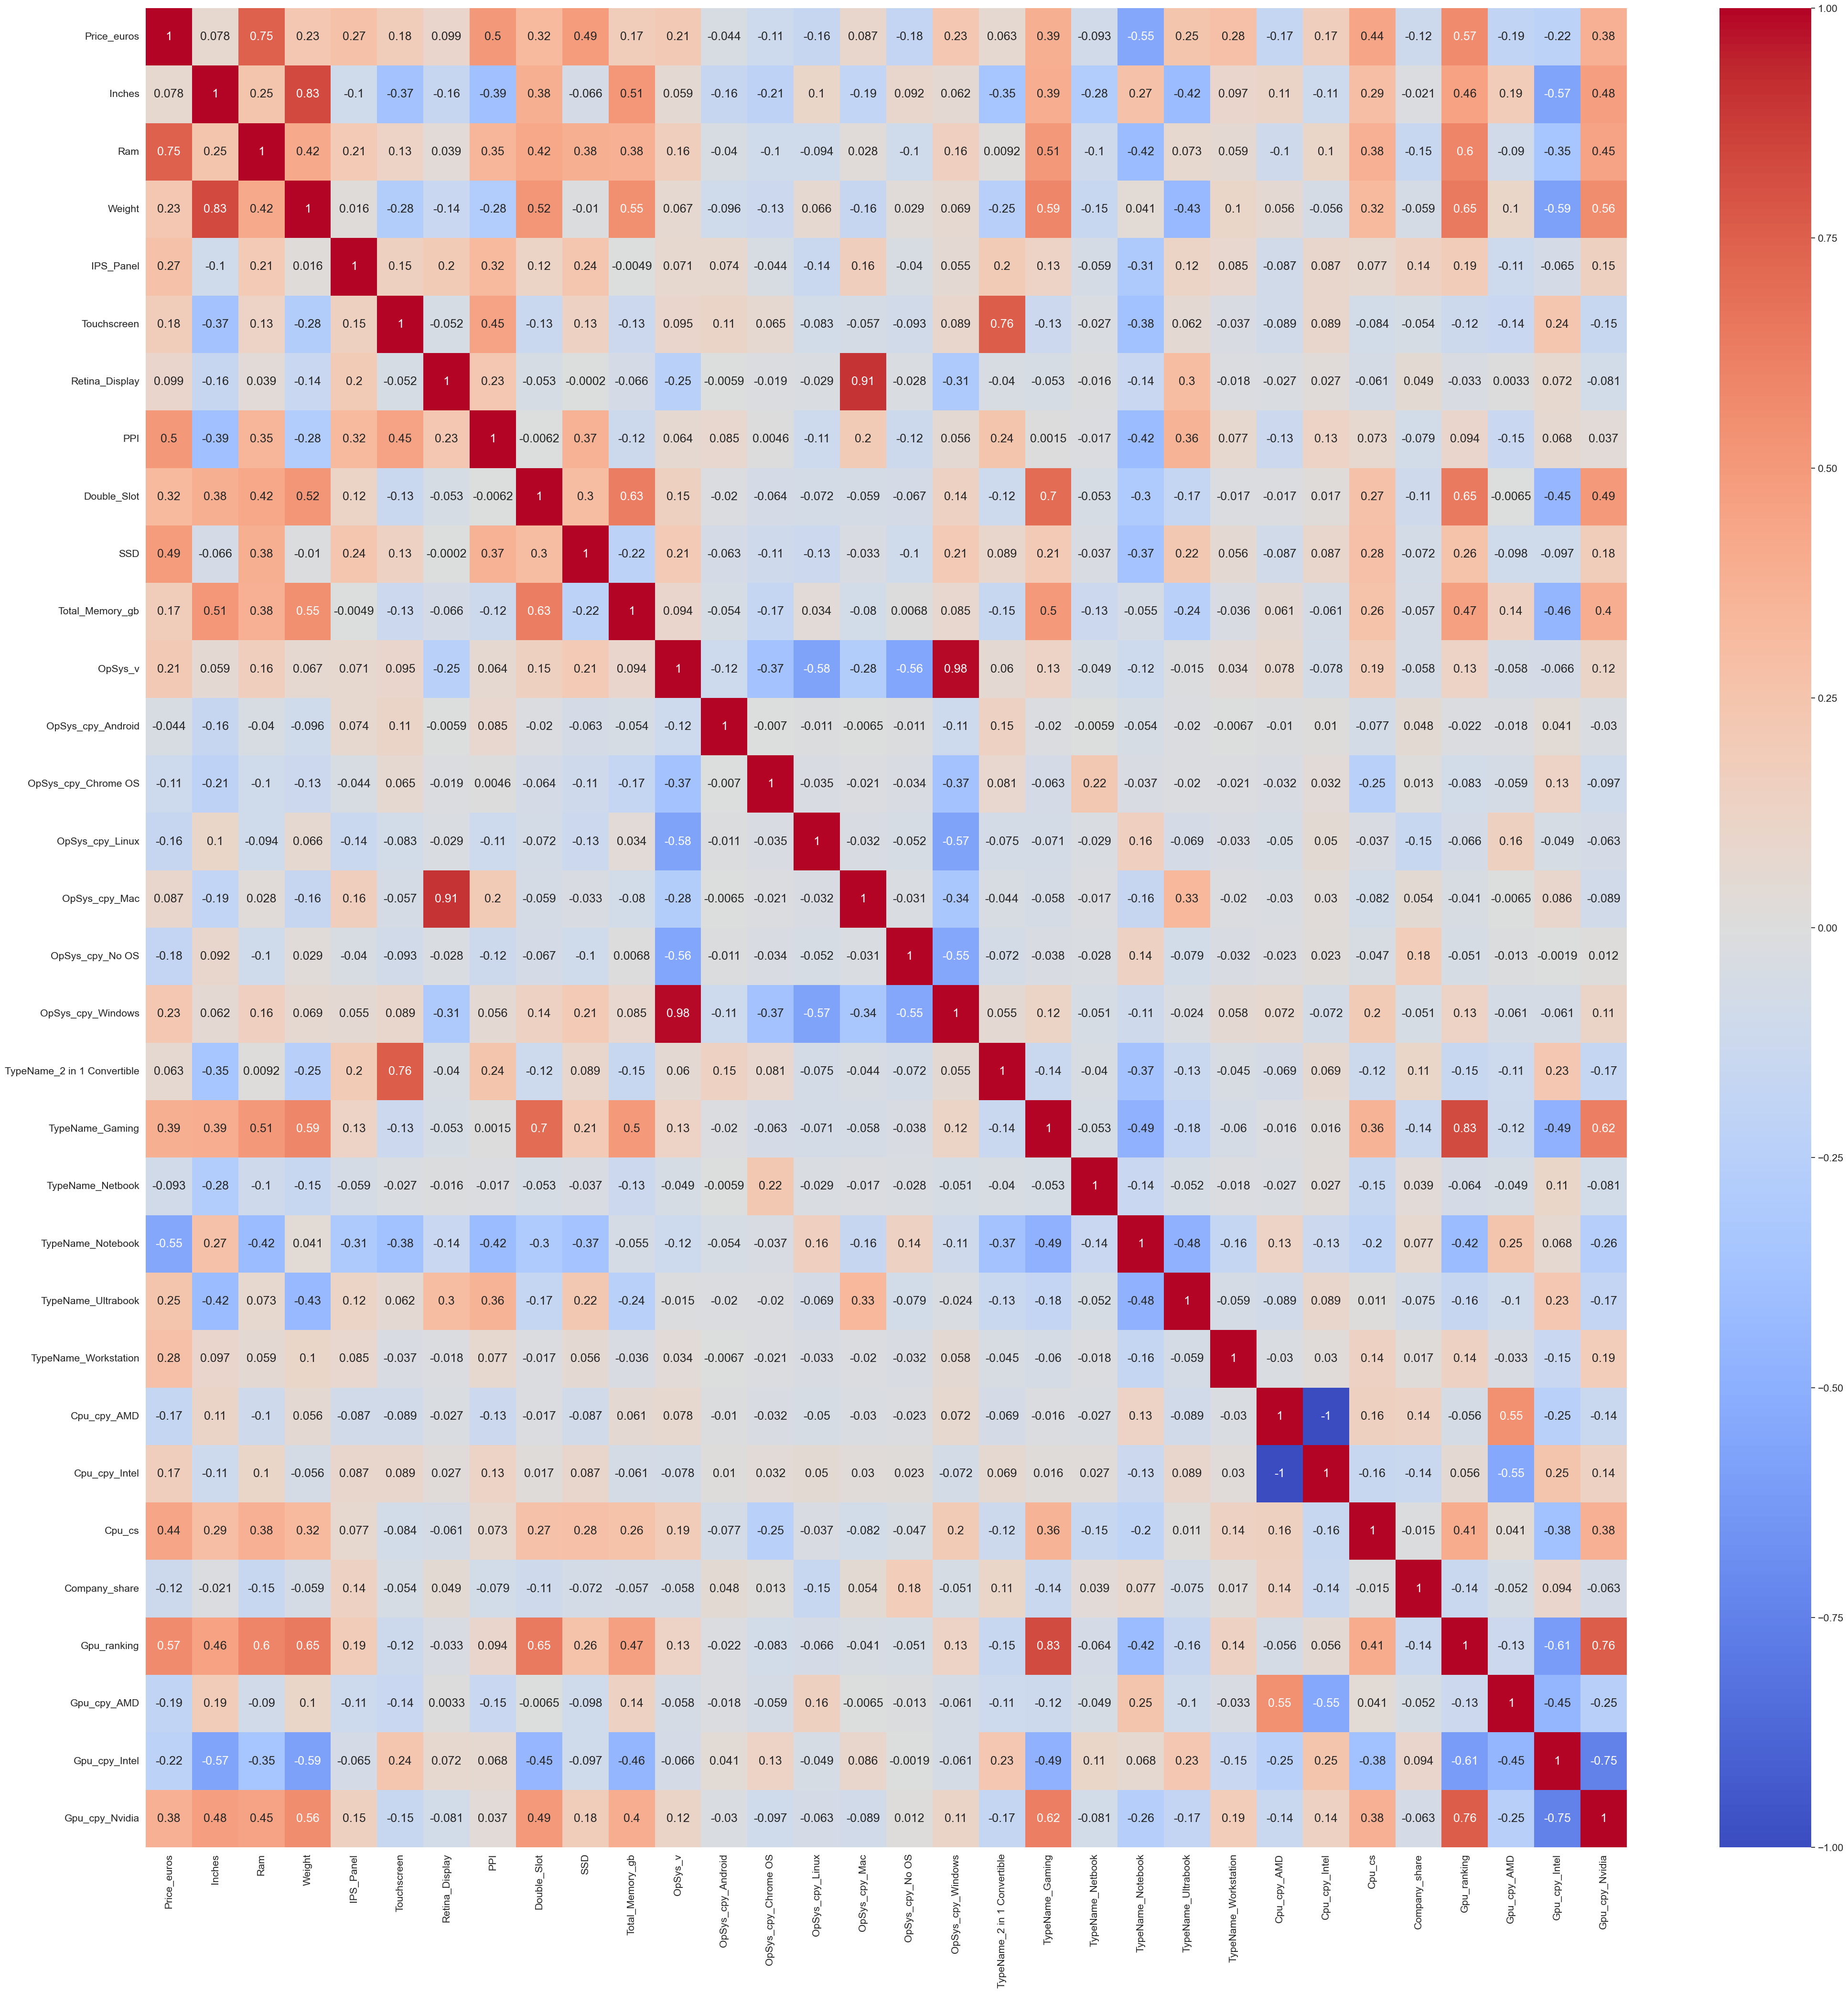

In [66]:
plt.figure(figsize=(50,50))
sns.set(font_scale=1.4)
sns.heatmap(df_numeric.corr(), cmap='coolwarm', vmin=-1, annot=True, annot_kws={'size': 18});

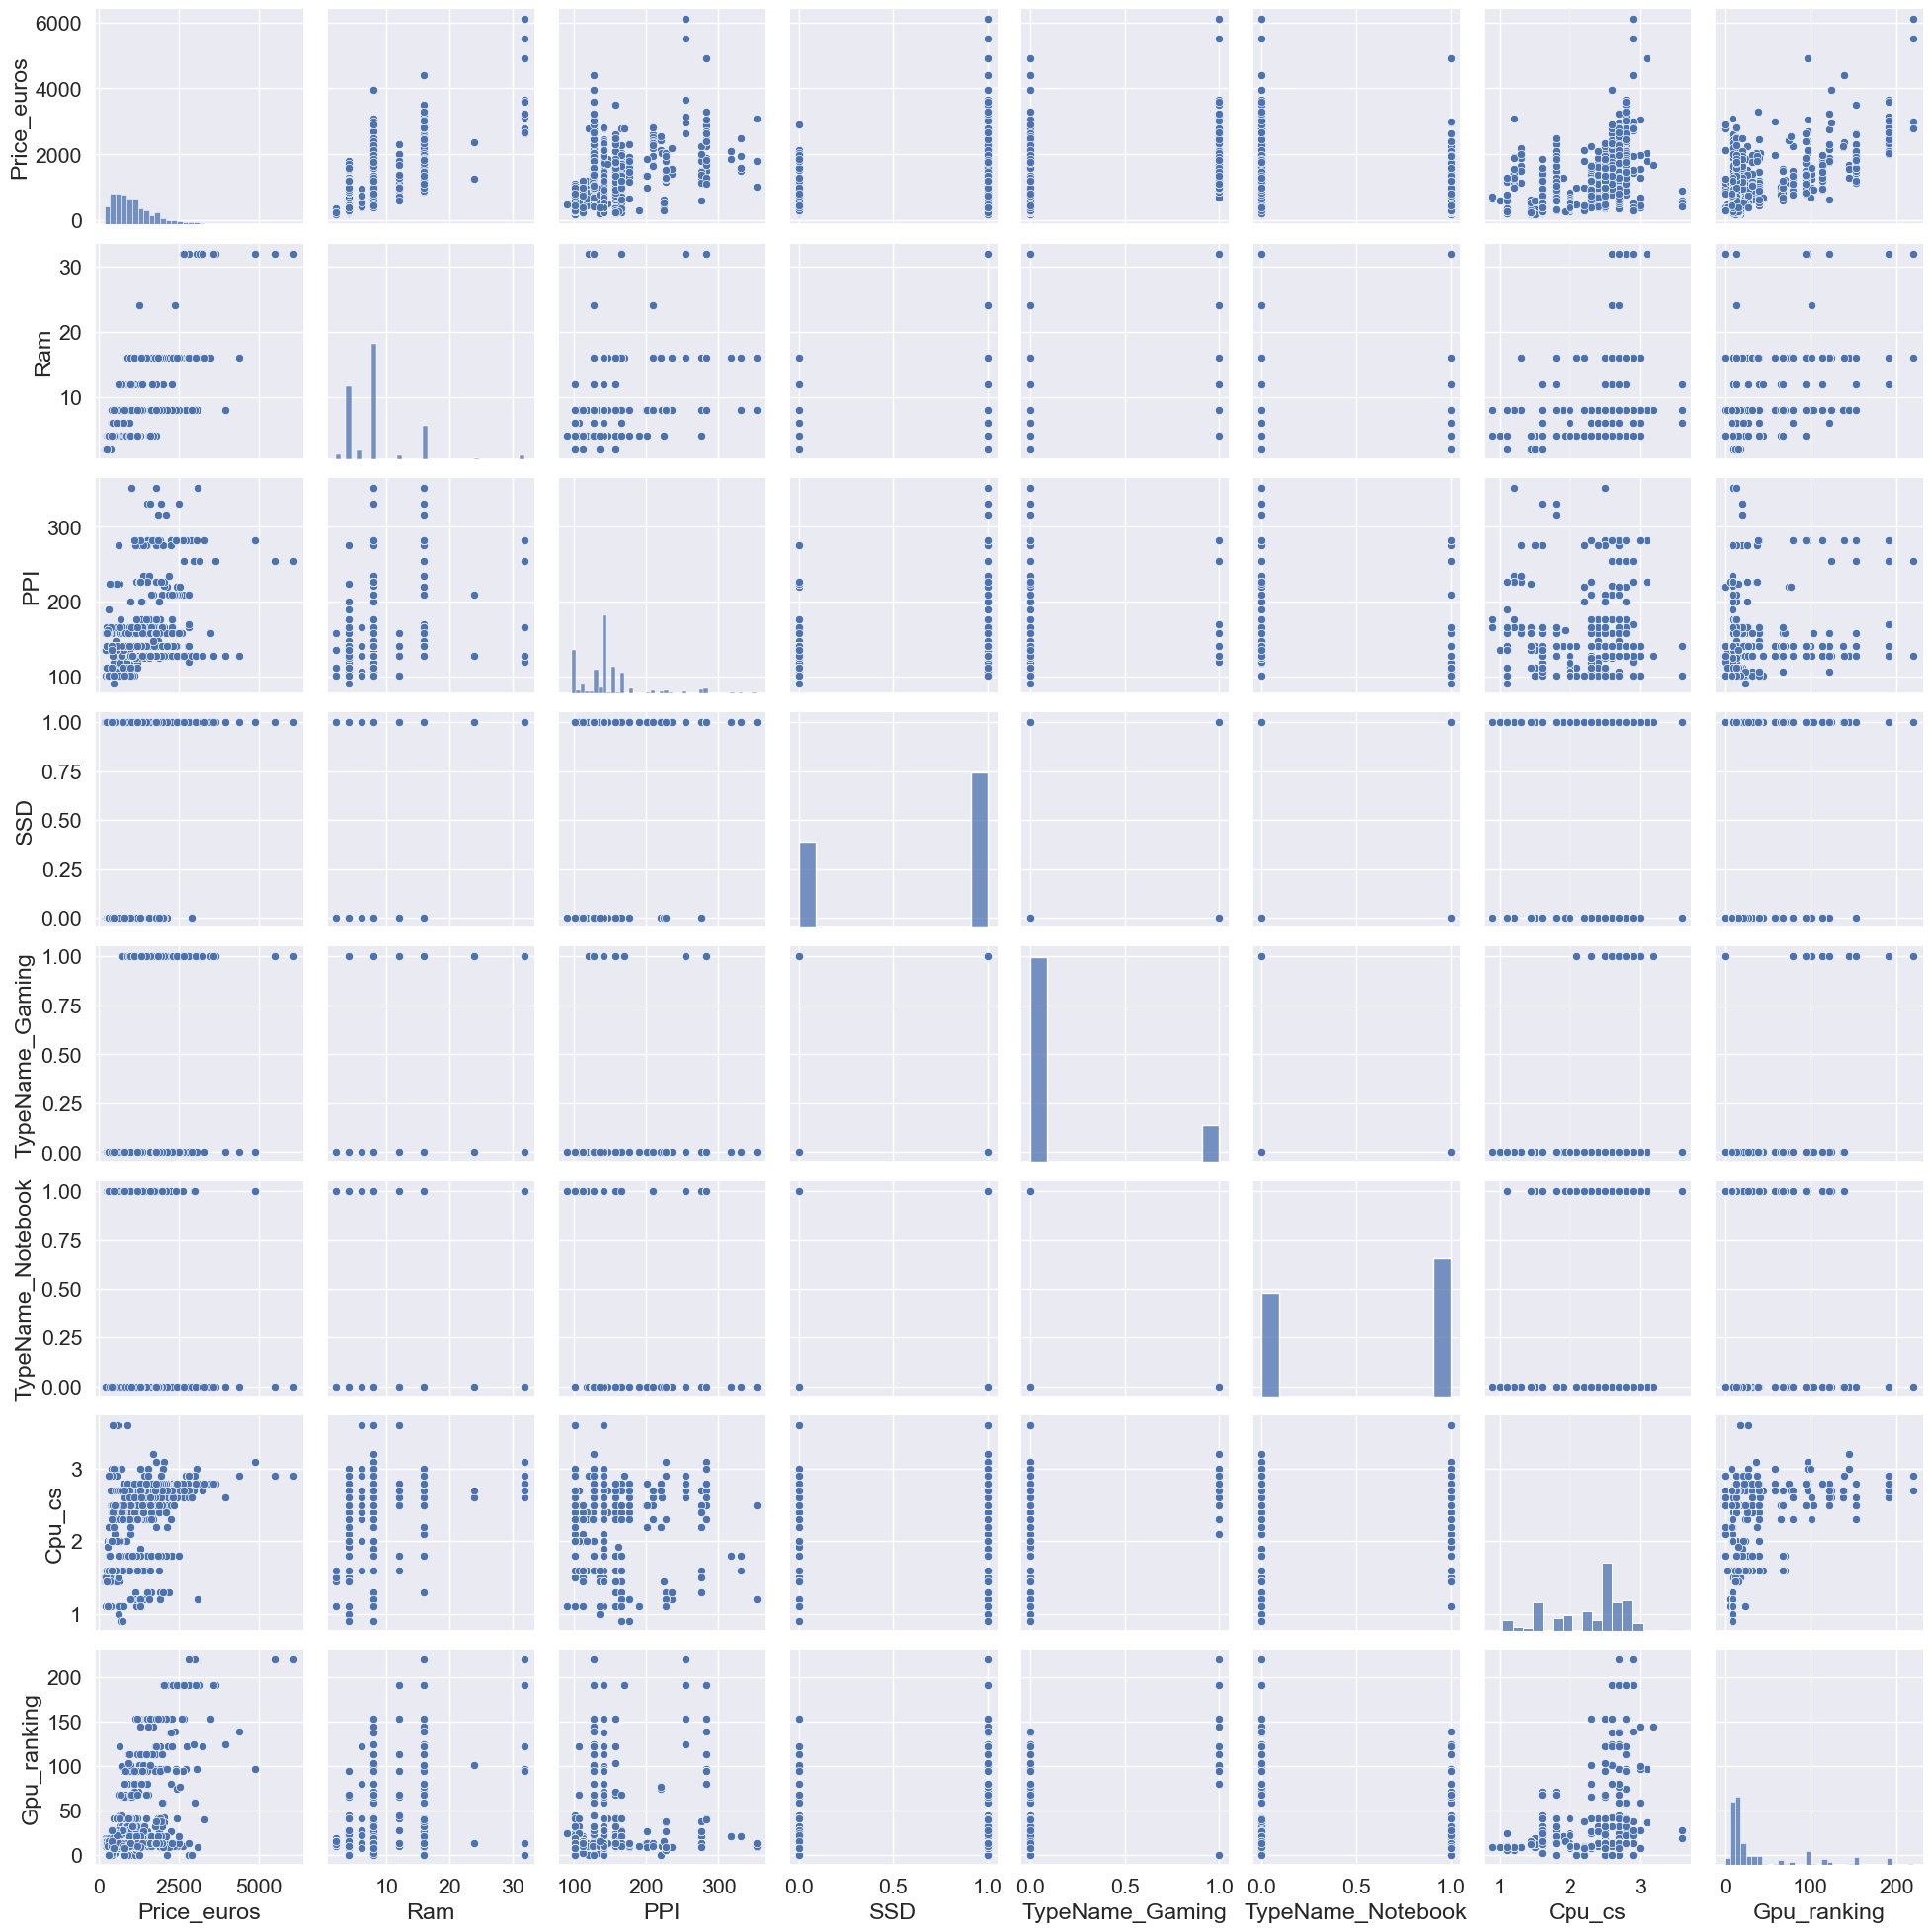

In [67]:

sns.pairplot(df_numeric[['Price_euros','Ram','PPI','SSD','TypeName_Gaming','TypeName_Notebook','Cpu_cs','Gpu_ranking']]);

In [68]:
y = df_numeric['Price_euros']
#We finally took all the numeric features
X = df_numeric.drop(columns='Price_euros')

In [69]:
validation_size = 0.20
seed = 7
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,
                                                                    y,
                                                                    test_size=validation_size,
                                                                    random_state=seed)

In [70]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

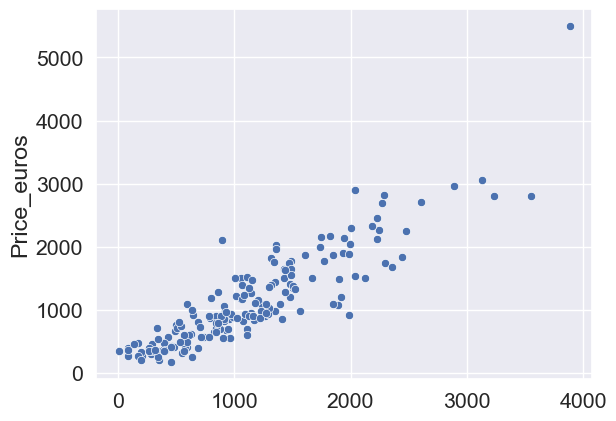

In [71]:
predictions = model.predict(X_test)
sns.scatterplot(x=predictions, y=Y_test);

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
print("MAE:", mean_absolute_error(Y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, predictions)))
print("r2_score train", model.score(X_train, Y_train))
print("r2_score test", model.score(X_test, Y_test))

MAE: 245.30650372243488
MAPE: 0.2686937126917863
MSE: 111587.46722238597
RMSE: 334.0471032989
r2_score train 0.7950798514016084
r2_score test 0.7916616723516308


In [73]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train_scal = scaler.transform(X_train)
lm_scal = LinearRegression()
lm_scal.fit(X_train_scal, Y_train)
predictions = lm_scal.predict(scaler.transform(X_test))
print("MAE:", mean_absolute_error(Y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, predictions)))
print("r2_score train", model.score(X_train, Y_train))
print("r2_score test", model.score(X_test, Y_test))


MAE: 245.30650372243448
MAPE: 0.2686937126917858
MSE: 111587.46722238576
RMSE: 334.0471032988997
r2_score train 0.7950798514016084
r2_score test 0.7916616723516308


In [74]:
predictions = lm_scal.predict(scaler.transform(X_test))
print("MAE:", mean_absolute_error(Y_test, predictions))
print("MAPE:", mean_absolute_percentage_error(Y_test, predictions))
print("MSE:", mean_squared_error(Y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, predictions)))
print("r2_score train", model.score(X_train, Y_train))
print("r2_score test", model.score(X_test, Y_test))

MAE: 245.30650372243448
MAPE: 0.2686937126917858
MSE: 111587.46722238576
RMSE: 334.0471032988997
r2_score train 0.7950798514016084
r2_score test 0.7916616723516308


For the moment scaler doesn't make much difference. Let's try with polynomial regression.

In [75]:
from sklearn.preprocessing import PolynomialFeatures

In [76]:
from sklearn.model_selection import cross_val_score
for i in range(2,5,1):
    poly_feats = PolynomialFeatures(degree = i)
    poly_feats.fit(X_train)
    X_poly = poly_feats.transform(X_train)
    pol_reg = LinearRegression()
    pol_reg.fit(X_poly, Y_train)
    predictions = pol_reg.predict(poly_feats.transform(X_test))
    print(f"MAE_Train for degree={i}:", mean_absolute_error(Y_train, pol_reg.predict(X_poly)))
    print(f"MAE_Test for degree={i}:", mean_absolute_error(Y_test, pol_reg.predict(poly_feats.transform(X_test))))
    print(f"MSE_Train for degree={i}:", mean_squared_error(Y_train, pol_reg.predict(X_poly)))
    print(f"MSE_Test for degree={i}:", mean_squared_error(Y_test, pol_reg.predict(poly_feats.transform(X_test))))
    print(f"r2_score train for degree={i}:", r2_score(Y_train, pol_reg.predict(X_poly)))
    print(f"r2_score test for degree={i}:", r2_score(Y_test, pol_reg.predict(poly_feats.transform(X_test))))
    print(cross_val_score(pol_reg, X_poly, Y_train, cv=5))

MAE_Train for degree=2: 130.70349362915778
MAE_Test for degree=2: 673.9697113955151
MSE_Train for degree=2: 31614.80813067206
MSE_Test for degree=2: 3817394.578299181
r2_score train for degree=2: 0.9372308771848173
r2_score test for degree=2: -6.127230523404631
[-24.48850625  -7.52824232   0.50694485 -12.42073913  -0.84402006]
MAE_Train for degree=3: 7.344954958944393
MAE_Test for degree=3: 71968.68826723176
MSE_Train for degree=3: 630.8847814337939
MSE_Test for degree=3: 138913120699.86127
r2_score train for degree=3: 0.9987474197482278
r2_score test for degree=3: -259355.4311066217
[-115082.18617377   -7593.09191323  -25973.45642998  -30042.67380902
  -16462.75759257]
MAE_Train for degree=4: 18.15595902572237
MAE_Test for degree=4: 11219.000213886999
MSE_Train for degree=4: 2043.3129632860744
MSE_Test for degree=4: 1547287108.3893082
r2_score train for degree=4: 0.9959431364627538
r2_score test for degree=4: -2887.847794271289
[-107764.99568666  -11558.44872288   -2167.15492332  -603

For the moment a degree 2 is what is performing the best, we'll try some regulation.

In [77]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
n_alphas = 100
alphas = np.arange(1,1000, 100)
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X_train)
X_poly = poly_feats.transform(X_train)
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_poly, Y_train)
    predictions = ridge.predict(poly_feats.transform(X_test))
    print(f"MSE_Train for alpha={a}:", mean_absolute_error(Y_train, ridge.predict(X_poly)))
    print(f"MSE_Test for alpha={a}:", mean_absolute_error(Y_test, ridge.predict(poly_feats.transform(X_test))))
    print(f"MSE_Train for alpha={a}:", mean_squared_error(Y_train, ridge.predict(X_poly)))
    print(f"MSE_Test for alpha={a}:", mean_squared_error(Y_test, ridge.predict(poly_feats.transform(X_test))))
    print(f"r2_score train for alpha={a}:", r2_score(Y_train, ridge.predict(X_poly)))
    print(f"r2_score test for alpha={a}:", r2_score(Y_test, ridge.predict(poly_feats.transform(X_test))))
    print(cross_val_score(ridge, X_poly, Y_train, cv=5))
    print('--------------------------------------------------------------')


MSE_Train for alpha=1: 144.83810303185965
MSE_Test for alpha=1: 273.23974546337
MSE_Train for alpha=1: 37341.02776277033
MSE_Test for alpha=1: 150840.02559456349
r2_score train for alpha=1: 0.9258618446141222
r2_score test for alpha=1: 0.7183755536616021
[ 0.70519862 -0.05560459  0.75892697  0.5327417   0.70215334]
--------------------------------------------------------------
MSE_Train for alpha=101: 172.6968786375058
MSE_Test for alpha=101: 231.99333655590854
MSE_Train for alpha=101: 54465.542716605625
MSE_Test for alpha=101: 115420.59059043396
r2_score train for alpha=101: 0.8918622461397326
r2_score test for alpha=101: 0.7845050755397551
[0.73807854 0.56145999 0.85724902 0.64080353 0.70764563]
--------------------------------------------------------------
MSE_Train for alpha=201: 175.46575648004875
MSE_Test for alpha=201: 226.8601636172654
MSE_Train for alpha=201: 57057.98452736501
MSE_Test for alpha=201: 113130.17506548058
r2_score train for alpha=201: 0.8867151233819988
r2_score 

In [78]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X_train)
X_poly = poly_feats.transform(X_train)
ridge = Ridge(alpha=235)
ridge.fit(X_poly, Y_train)
predictions = ridge.predict(poly_feats.transform(X_test))
print(f"MAE_Train:", mean_absolute_error(Y_train, ridge.predict(X_poly)))
print(f"MAE_Test:", mean_absolute_error(Y_test, ridge.predict(poly_feats.transform(X_test))))
print(f"MSE_Train:", mean_squared_error(Y_train, ridge.predict(X_poly)))
print(f"MSE_Test:", mean_squared_error(Y_test, ridge.predict(poly_feats.transform(X_test))))
print(f"r2_score train:", r2_score(Y_train, ridge.predict(X_poly)))
print(f"r2_score test:", r2_score(Y_test, ridge.predict(poly_feats.transform(X_test))))
print(cross_val_score(ridge, X_poly, Y_train, cv=5))

MAE_Train: 175.98283015276778
MAE_Test: 225.6009708638081
MSE_Train: 57602.644019875115
MSE_Test: 112489.53581925931
r2_score train: 0.8856337377719228
r2_score test: 0.789977473690484
[0.7454669  0.62335115 0.85846582 0.65461816 0.69956703]


In [79]:
from sklearn.linear_model import ElasticNet
elastic_net_risk = ElasticNet(alpha = 11, l1_ratio=0.1,max_iter=150000,random_state=7)
elastic_net_risk.fit(X_poly, Y_train) 
predictions = elastic_net_risk.predict(poly_feats.transform(X_test))
print(f"MAE_Train:", mean_absolute_error(Y_train, elastic_net_risk.predict(X_poly)))
print(f"MAE_Test:", mean_absolute_error(Y_test, elastic_net_risk.predict(poly_feats.transform(X_test))))
print(f"MSE_Train:", mean_squared_error(Y_train, elastic_net_risk.predict(X_poly)))
print(f"MSE_Test:", mean_squared_error(Y_test, elastic_net_risk.predict(poly_feats.transform(X_test))))
print(f"r2_score train:", r2_score(Y_train, elastic_net_risk.predict(X_poly)))
print(f"r2_score test:", r2_score(Y_test, elastic_net_risk.predict(poly_feats.transform(X_test))))
print(cross_val_score(elastic_net_risk, X_poly, Y_train, cv=5))

MAE_Train: 187.8720479782083
MAE_Test: 212.56539744973188
MSE_Train: 69361.45173505878
MSE_Test: 104382.02327453555
r2_score train: 0.8622873982153527
r2_score test: 0.8051145284780943
[0.77710268 0.75230062 0.85462225 0.70944295 0.71448517]


In [80]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 235, l1_ratio=0.01, max_iter=50000, random_state=7)
elastic_net.fit(X_poly, Y_train) 
predictions = elastic_net.predict(poly_feats.transform(X_test))
print(f"MAE_Train:", mean_absolute_error(Y_train, elastic_net.predict(X_poly)))
print(f"MAE_Test:", mean_absolute_error(Y_test, elastic_net.predict(poly_feats.transform(X_test))))
print(f"MSE_Train:", mean_squared_error(Y_train, elastic_net.predict(X_poly)))
print(f"MSE_Test:", mean_squared_error(Y_test, elastic_net.predict(poly_feats.transform(X_test))))
print(f"r2_score train:", r2_score(Y_train, elastic_net.predict(X_poly)))
print(f"r2_score test:", r2_score(Y_test, elastic_net.predict(poly_feats.transform(X_test))))
print(cross_val_score(elastic_net, X_poly, Y_train, cv=5))

MAE_Train: 204.99669358259288
MAE_Test: 206.87524557643718
MSE_Train: 82816.68364596996
MSE_Test: 95365.45986531493
r2_score train: 0.8355729199609881
r2_score test: 0.8219488181037276
[0.74396171 0.78270218 0.8481436  0.70692682 0.72794046]


In [81]:
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X_train)
X_poly = poly_feats.transform(X_train)
ridge_crazy = Ridge(alpha=0.89)
ridge_crazy.fit(X_poly, Y_train)
predictions = ridge.predict(poly_feats.transform(X_test))
print(f"MAE_Train:", mean_absolute_error(Y_train, ridge_crazy.predict(X_poly)))
print(f"MAE_Test:", mean_absolute_error(Y_test, ridge_crazy.predict(poly_feats.transform(X_test))))
print(f"MSE_Train:", mean_squared_error(Y_train, ridge_crazy.predict(X_poly)))
print(f"MSE_Test:", mean_squared_error(Y_test, ridge_crazy.predict(poly_feats.transform(X_test))))
print(f"r2_score train:", r2_score(Y_train, ridge_crazy.predict(X_poly)))
print(f"r2_score test:", r2_score(Y_test, ridge_crazy.predict(poly_feats.transform(X_test))))
print(cross_val_score(ridge_crazy, X_poly, Y_train, cv=5))

MAE_Train: 144.32874713224376
MAE_Test: 274.50876167964594
MSE_Train: 37090.75162519201
MSE_Test: 152626.88582995321
r2_score train: 0.9263587514291954
r2_score test: 0.7150394131213696
[ 0.70228919 -0.06935772  0.75555827  0.52587449  0.69727592]


In [85]:
#Dataset Test Transformation
kaggle_test = pd.read_csv('data/test.csv')
pattern = r"^(.*?)(\d{3,4}x\d{3,4})$" #
kaggle_test[['ScreenType', 'Resolution']] = kaggle_test['ScreenResolution'].str.extract(pattern)
kaggle_test['ScreenType'] = kaggle_test['ScreenType'].str.strip()
kaggle_test['Resolution'] = kaggle_test['Resolution'].str.strip()
kaggle_test['IPS_Panel'] = np.where(kaggle_test['ScreenType'].str.contains('IPS Panel', na=False), 1, 0)
kaggle_test['Touchscreen'] = np.where(kaggle_test['ScreenType'].str.contains('Touchscreen', na=False), 1, 0)
kaggle_test['Retina_Display'] = np.where(kaggle_test['ScreenType'].str.contains('Retina Display', na=False), 1, 0)
kaggle_test[['Width','Height']] = kaggle_test["Resolution"].str.split("x", expand=True).astype(int)
kaggle_test['PPI'] = np.round(((np.sqrt(kaggle_test['Width']**2 + kaggle_test['Height']**2)) / kaggle_test['Inches']), 2)
kaggle_test['Weight'] = kaggle_test['Weight'].str.extract(r"(\d+(\.\d+)?)\s*kg")[0].astype(float)
kaggle_test['Double_Slot'] = np.where(kaggle_test['Memory'].str.contains(r'\+', na=False), 1, 0)
kaggle_test['SSD'] = np.where(kaggle_test['Memory'].str.contains(r'\SSD', na=False), 1, 0)
kaggle_test['Total_Memory_gb'] = kaggle_test['Memory'].apply(extract_total_memory)
kaggle_test['Ram'] = kaggle_test['Ram'].str.extract(r"(\d+(\.\d+)?)\s*GB")[0].astype(float)
kaggle_test['OpSys_cpy'] = kaggle_test['OpSys'].apply(opsys_classifier)
kaggle_test['OpSys_v'] = kaggle_test['OpSys'].apply(opsys_get_version)
kaggle_test = pd.get_dummies(kaggle_test, columns=['OpSys_cpy'], dtype=int)
kaggle_test = pd.get_dummies(kaggle_test, columns=['TypeName'], dtype=int)
kaggle_test['Cpu_cpy'] = kaggle_test['Cpu'].str.split(" ").str[0]
kaggle_test = pd.get_dummies(kaggle_test, columns=['Cpu_cpy'], dtype=int)
kaggle_test['Cpu_cs'] =kaggle_test['Cpu'].str.split(' ').str[-1].str.extract(r'([\d\.]+)\s*GHz').astype(float)
kaggle_test['Company_share'] = kaggle_test['Company'].str.lower().map(market_share).fillna(0)
kaggle_test['Gpu_ranking'] = kaggle_test['Gpu'].apply(lambda x: fuzzy_match_gpu(x, gpu_map))
kaggle_test['Gpu_cpy'] = kaggle_test['Gpu'].str.split(" ").str[0]
kaggle_test = pd.get_dummies(kaggle_test, columns=['Gpu_cpy'], dtype=int)

kaggle_test.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Cpu_cpy_AMD,Cpu_cpy_Intel,Cpu_cpy_Samsung,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_ARM,Gpu_cpy_Intel,Gpu_cpy_Nvidia
0,181,1098,HP,Spectre x360,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16.0,512GB SSD,Intel HD Graphics 620,...,0,1,0,2.7,16.5,14,0,0,1,0
1,708,330,Acer,Aspire 5,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8.0,256GB SSD,AMD Radeon RX 540,...,1,0,0,2.7,11.7,145,1,0,0,0
2,862,1260,Acer,Aspire ES1-572,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4.0,500GB HDD,Intel HD Graphics 520,...,0,1,0,2.0,11.7,10,0,0,1,0
3,1064,1137,HP,EliteBook 1040,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,0,1,0,2.3,16.5,10,0,0,1,0
4,702,1015,HP,ENVY -,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,...,0,1,0,2.5,16.5,14,0,0,1,0


In [86]:
kaggle_x = kaggle_test[['Inches','Ram','Weight','IPS_Panel', 'Touchscreen',
       'Retina_Display','PPI', 'Double_Slot', 'SSD',
       'Total_Memory_gb', 'OpSys_v',
       'OpSys_cpy_Chrome OS', 'OpSys_cpy_Linux', 'OpSys_cpy_Mac',
       'OpSys_cpy_No OS', 'OpSys_cpy_Windows', 'TypeName_2 in 1 Convertible',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'Cpu_cpy_AMD',
       'Cpu_cpy_Intel', 'Cpu_cs', 'Company_share', 'Gpu_ranking',
       'Gpu_cpy_AMD', 'Gpu_cpy_Intel', 'Gpu_cpy_Nvidia']]
kaggle_x['OpSys_cpy_Android'] = 0
kaggle_x = kaggle_x[['Inches','Ram','Weight','IPS_Panel', 'Touchscreen',
       'Retina_Display','PPI', 'Double_Slot', 'SSD',
       'Total_Memory_gb', 'OpSys_v', 'OpSys_cpy_Android',
       'OpSys_cpy_Chrome OS', 'OpSys_cpy_Linux', 'OpSys_cpy_Mac',
       'OpSys_cpy_No OS', 'OpSys_cpy_Windows', 'TypeName_2 in 1 Convertible',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'Cpu_cpy_AMD',
       'Cpu_cpy_Intel', 'Cpu_cs', 'Company_share', 'Gpu_ranking',
       'Gpu_cpy_AMD', 'Gpu_cpy_Intel', 'Gpu_cpy_Nvidia']]
kaggle_x.head()

C:\Users\Nacho MPra\AppData\Local\Temp\ipykernel_33972\2534981050.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kaggle_x['OpSys_cpy_Android'] = 0


,Inches,Ram,Weight,IPS_Panel,Touchscreen,Retina_Display,PPI,Double_Slot,SSD,Total_Memory_gb,...,TypeName_Ultrabook,TypeName_Workstation,Cpu_cpy_AMD,Cpu_cpy_Intel,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_Intel,Gpu_cpy_Nvidia
0,13.3,16.0,1.30,1,0,0,331.26,0,1,512.0,...,1,0,0,1,2.7,16.5,14,0,1,0
1,15.6,8.0,2.20,0,0,0,100.45,0,1,256.0,...,0,0,1,0,2.7,11.7,145,1,0,0
2,15.6,4.0,2.40,0,0,0,100.45,0,0,500.0,...,0,0,0,1,2.0,11.7,10,0,1,0
3,14.0,8.0,1.43,0,0,0,157.35,0,1,256.0,...,0,0,0,1,2.3,16.5,10,0,1,0
4,13.3,8.0,1.34,1,0,0,165.63,0,1,256.0,...,0,0,0,1,2.5,16.5,14,0,1,0


In [87]:
kaggle_ridge = kaggle_test
kaggle_ridge['Price_euros'] = ridge.predict(poly_feats.transform(kaggle_x))
kaggle_ridge[['id','Price_euros']].to_csv('outputs/only_ridge.csv',index = False, header=True)
kaggle_ridge.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Cpu_cpy_Intel,Cpu_cpy_Samsung,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_ARM,Gpu_cpy_Intel,Gpu_cpy_Nvidia,Price_euros
0,181,1098,HP,Spectre x360,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16.0,512GB SSD,Intel HD Graphics 620,...,1,0,2.7,16.5,14,0,0,1,0,2309.782053
1,708,330,Acer,Aspire 5,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8.0,256GB SSD,AMD Radeon RX 540,...,0,0,2.7,11.7,145,1,0,0,0,1565.634213
2,862,1260,Acer,Aspire ES1-572,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4.0,500GB HDD,Intel HD Graphics 520,...,1,0,2.0,11.7,10,0,0,1,0,354.190526
3,1064,1137,HP,EliteBook 1040,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,1,0,2.3,16.5,10,0,0,1,0,1495.437950
4,702,1015,HP,ENVY -,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,...,1,0,2.5,16.5,14,0,0,1,0,1163.955430


In [88]:
kaggle_en_risk = kaggle_test
kaggle_en_risk['Price_euros'] = elastic_net_risk.predict(poly_feats.transform(kaggle_x))
kaggle_en_risk[['id','Price_euros']].to_csv('outputs/elasticnet_risk.csv',index = False, header=True)
kaggle_en_risk.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Cpu_cpy_Intel,Cpu_cpy_Samsung,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_ARM,Gpu_cpy_Intel,Gpu_cpy_Nvidia,Price_euros
0,181,1098,HP,Spectre x360,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16.0,512GB SSD,Intel HD Graphics 620,...,1,0,2.7,16.5,14,0,0,1,0,2375.028684
1,708,330,Acer,Aspire 5,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8.0,256GB SSD,AMD Radeon RX 540,...,0,0,2.7,11.7,145,1,0,0,0,1699.101802
2,862,1260,Acer,Aspire ES1-572,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4.0,500GB HDD,Intel HD Graphics 520,...,1,0,2.0,11.7,10,0,0,1,0,334.970627
3,1064,1137,HP,EliteBook 1040,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,1,0,2.3,16.5,10,0,0,1,0,1411.500076
4,702,1015,HP,ENVY -,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,...,1,0,2.5,16.5,14,0,0,1,0,1162.345304


In [89]:
kaggle_en_stable = kaggle_test
kaggle_en_stable['Price_euros'] = elastic_net.predict(poly_feats.transform(kaggle_x))
kaggle_en_stable[['id','Price_euros']].to_csv('outputs/elsaticnet_stable.csv',index = False, header=True)
kaggle_en_stable.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Cpu_cpy_Intel,Cpu_cpy_Samsung,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_ARM,Gpu_cpy_Intel,Gpu_cpy_Nvidia,Price_euros
0,181,1098,HP,Spectre x360,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16.0,512GB SSD,Intel HD Graphics 620,...,1,0,2.7,16.5,14,0,0,1,0,2502.215420
1,708,330,Acer,Aspire 5,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8.0,256GB SSD,AMD Radeon RX 540,...,0,0,2.7,11.7,145,1,0,0,0,1647.480090
2,862,1260,Acer,Aspire ES1-572,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4.0,500GB HDD,Intel HD Graphics 520,...,1,0,2.0,11.7,10,0,0,1,0,328.054072
3,1064,1137,HP,EliteBook 1040,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,1,0,2.3,16.5,10,0,0,1,0,1274.092664
4,702,1015,HP,ENVY -,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,...,1,0,2.5,16.5,14,0,0,1,0,1153.330616


In [90]:
kaggle_ridge_crazy = kaggle_test
kaggle_ridge_crazy['Price_euros'] = ridge_crazy.predict(poly_feats.transform(kaggle_x))
kaggle_ridge_crazy[['id','Price_euros']].to_csv('outputs/crazy_ridge.csv',index = False, header=True)
kaggle_ridge_crazy.head()

,id,laptop_ID,Company,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,...,Cpu_cpy_Intel,Cpu_cpy_Samsung,Cpu_cs,Company_share,Gpu_ranking,Gpu_cpy_AMD,Gpu_cpy_ARM,Gpu_cpy_Intel,Gpu_cpy_Nvidia,Price_euros
0,181,1098,HP,Spectre x360,13.3,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7500U 2.7GHz,16.0,512GB SSD,Intel HD Graphics 620,...,1,0,2.7,16.5,14,0,0,1,0,2277.576528
1,708,330,Acer,Aspire 5,15.6,1366x768,AMD A12-Series 9720P 2.7GHz,8.0,256GB SSD,AMD Radeon RX 540,...,0,0,2.7,11.7,145,1,0,0,0,2104.170349
2,862,1260,Acer,Aspire ES1-572,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4.0,500GB HDD,Intel HD Graphics 520,...,1,0,2.0,11.7,10,0,0,1,0,284.791844
3,1064,1137,HP,EliteBook 1040,14.0,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8.0,256GB SSD,Intel HD Graphics 520,...,1,0,2.3,16.5,10,0,0,1,0,1540.465749
4,702,1015,HP,ENVY -,13.3,IPS Panel Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,...,1,0,2.5,16.5,14,0,0,1,0,1156.243222
